In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('./MNRAS.mplstyle')

import os, glob
import h5py

In [2]:
def _read_h5_dataset(dset):
    out = dset[()]

    if isinstance(out, (bytes, np.bytes_)):
        return out.decode("utf-8")

    if isinstance(out, np.ndarray):
        if out.dtype.kind == "S":
            return out.astype(str)
        if out.dtype == object:
            # variable-length strings sometimes come back as object arrays of bytes
            decode = np.vectorize(
                lambda x: x.decode("utf-8") if isinstance(x, (bytes, np.bytes_)) else x,
                otypes=[object],
            )
            return decode(out)
        return out

    if isinstance(out, np.generic):
        return out.item()

    return out

def _read_h5_item(obj):
    if isinstance(obj, h5py.Dataset):
        return _read_h5_dataset(obj)

    kind = obj.attrs.get("_kind_", "dict")
    if isinstance(kind, (bytes, np.bytes_)):
        kind = kind.decode("utf-8")

    if kind == "dict":
        return {k: _read_h5_item(obj[k]) for k in obj.keys()}

    if kind == "list":
        keys = sorted(obj.keys(), key=lambda x: int(x))
        return [_read_h5_item(obj[k]) for k in keys]

    if kind == "tuple":
        keys = sorted(obj.keys(), key=lambda x: int(x))
        return tuple(_read_h5_item(obj[k]) for k in keys)

    if kind == "none":
        return None

    raise ValueError(f"Unknown HDF5 node kind: {kind}")

def load_nested_hdf5(filename):
    """
    Load a nested payload (dict) from HDF5.
    """
    out = {}
    with h5py.File(filename, "r") as f:
        for k in f.keys():
            out[k] = _read_h5_item(f[k])
    return out

def ratio_and_err(num, num_err, den, den_err):
    num = np.asarray(num, dtype=float)
    num_err = np.asarray(num_err, dtype=float)
    den = np.asarray(den, dtype=float)
    den_err = np.asarray(den_err, dtype=float)

    ratio = np.full_like(num, np.nan, dtype=float)
    ratio_err = np.full_like(num, np.nan, dtype=float)

    valid = (num != 0.0) & (den != 0.0)

    ratio[valid] = num[valid] / den[valid]
    ratio_err[valid] = np.abs(ratio[valid]) * np.sqrt(
        (num_err[valid] / num[valid])**2 +
        (den_err[valid] / den[valid])**2
    )
    return ratio, ratio_err

file_name    = "mean_lensing_hm-ranked_AM_DESY3_projdepth300cMpch.hdf5"
lensing_data = load_nested_hdf5(file_name) 

res    = lensing_data["res"]
rp     = np.asarray(lensing_data["plot_data"]["rp_bins"])
counts = np.asarray(lensing_data["plot_data"]["counts"])

tag        = lensing_data["meta"]["tag"]
redshift   = lensing_data["meta"]["redshift"]
proj_depth = lensing_data["meta"]["proj_depth_cMpc_h"]

print("tag        =", tag)
print("redshift   =", redshift)
print("proj_depth =", proj_depth)
print("counts     =", counts)

tag        = DESY3
redshift   = 0.3
proj_depth = 300
counts     = [ 257  370 1103 2396]


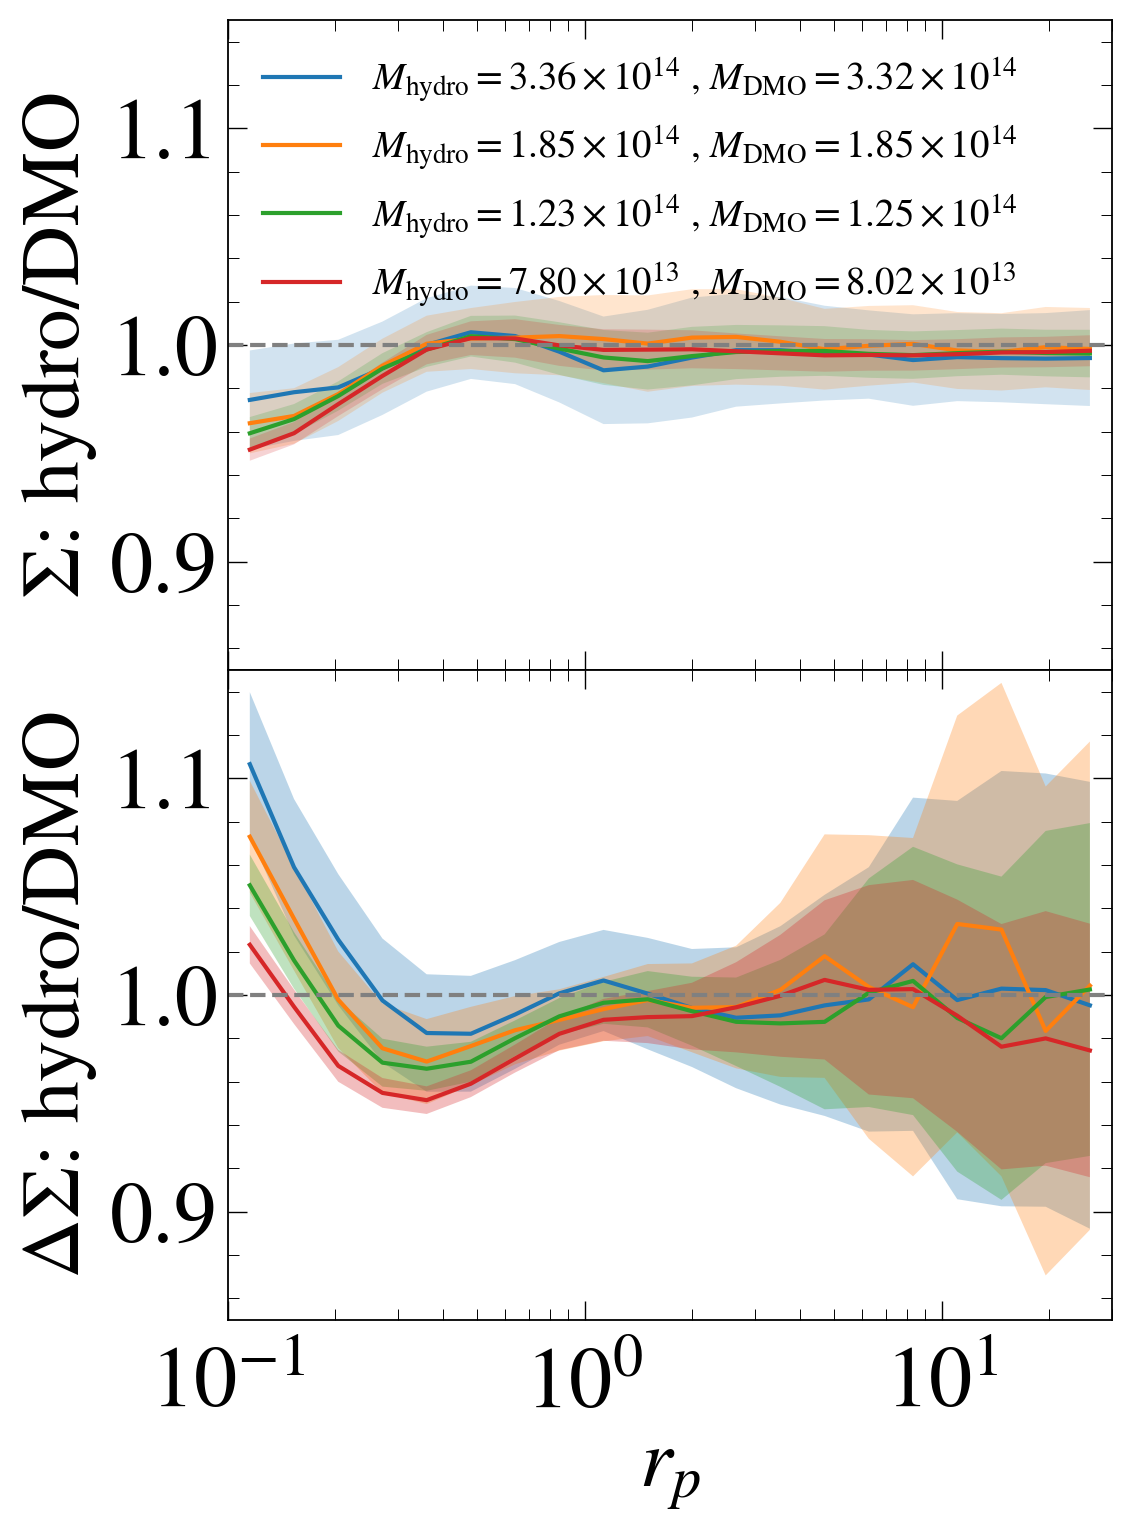

In [10]:
fig, axes = plt.subplots(
    2, 1,
    sharex=True,
    figsize=(6, 8),
    gridspec_kw={'hspace': 0}
)

# loop through 4 mass-ranked abundance bins

nbin = 4 
for ibin in range(nbin):

    # ----------- TODO: placeholder  ----------- 
    # rp = np.geomspace(0.1, 30)
    # Sigma = 0*rp+1.05 
    # DeltaSigma = Sigma 
    # err = 0*rp+0.01

    # ---------- Sigma ----------
    Sig_hydro_mean = np.asarray(
        res["bins"][ibin]["mean_lensing"]["Hydro DMGasStars"]["Sigma_mean"]
    )
    Sig_hydro_err = np.asarray(
        res["bins"][ibin]["mean_lensing"]["Hydro DMGasStars"]["Sigma_err"]
    )

    Sig_dmo_mean = np.asarray(
        res["bins"][ibin]["mean_lensing"]["DMO"]["Sigma_mean"]
    )
    Sig_dmo_err = np.asarray(
        res["bins"][ibin]["mean_lensing"]["DMO"]["Sigma_err"]
    )

    ratio_sig_mean, ratio_sig_err = ratio_and_err(
        Sig_hydro_mean, Sig_hydro_err,
        Sig_dmo_mean, Sig_dmo_err
    )
    # ---------- DeltaSigma ----------
    DS_hydro_mean = np.asarray(
        res["bins"][ibin]["mean_lensing"]["Hydro DMGasStars"]["DeltaSigma_mean"]
    )
    DS_hydro_err = np.asarray(
        res["bins"][ibin]["mean_lensing"]["Hydro DMGasStars"]["DeltaSigma_err"]
    )

    DS_dmo_mean = np.asarray(
        res["bins"][ibin]["mean_lensing"]["DMO"]["DeltaSigma_mean"]
    )
    DS_dmo_err = np.asarray(
        res["bins"][ibin]["mean_lensing"]["DMO"]["DeltaSigma_err"]
    )

    ratio_ds_mean, ratio_ds_err = ratio_and_err(
        DS_hydro_mean, DS_hydro_err,
        DS_dmo_mean, DS_dmo_err
    )
    
    # ---------------------- 

    # top panel for Sigma

    # add the mean mass of each sample
    mean_hm_hydro = res["bins"][ibin]["mass_hydro"]["mean"] # Msun/h
    mean_hm_dmo = res["bins"][ibin]["mass_dmo"]["mean"] # Msun/h
    # mmin_hydro = res["bins"][ibin]["mass_hydro"]["min"]
    # mmax_hydro = res["bins"][ibin]["mass_hydro"]["max"]
    # mmin_dmo   = res["bins"][ibin]["mass_dmo"]["min"]
    # mmax_dmo   = res["bins"][ibin]["mass_dmo"]["max"]
    #label=rf'$M_{{\rm hydro}}={mean_hm_hydro:.2e} , M_{{\rm DMO}}={mean_hm_dmo:.2e}~[h^{{-1}}M_\odot]$'
    
    
    mantissa, exp = f"{mean_hm_hydro:.2e}".split("e")
    mean_hm_hydro = f"${mantissa}\\times 10^{{{int(exp)}}}$"
    mantissa, exp = f"{mean_hm_dmo:.2e}".split("e")
    mean_hm_dmo = f"${mantissa}\\times 10^{{{int(exp)}}}$"    
    label = rf'$M_{{\rm hydro}}=${mean_hm_hydro} , $M_{{\rm DMO}}=${mean_hm_dmo}'
    line = axes[0].plot(rp, ratio_sig_mean, label=label)
    axes[0].fill_between(rp, ratio_sig_mean-ratio_sig_err, ratio_sig_mean+ratio_sig_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.2)
    
    # bottom panel for DeltaSigma
    line = axes[1].plot(rp, ratio_ds_mean)
    axes[1].fill_between(rp, ratio_ds_mean-ratio_ds_err, ratio_ds_mean+ratio_ds_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.3)


axes[0].set_ylabel(r'$\Sigma$: hydro/DMO')
axes[1].set_ylabel(r'$\Delta\Sigma$: hydro/DMO')


axes[0].tick_params(labelbottom=False)
axes[1].set_xlabel(r'$r_p$')
axes[0].legend(fontsize=14)

for ipanel in [0, 1]:
    ax = axes[ipanel]
    ax.axhline(1, c='gray', ls='--')
    ax.set_ylim(0.85, 1.15)
    ax.set_xlim(0.1, 30)
    ax.set_xscale('log')        
    ax.grid(False)
#plt.show()

plt.savefig('../plots/lensing_hydro_dmo.pdf')